In [1]:
from medmnist import BreastMNIST
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import torchvision.models as models
import gc

# Preprocess

In [2]:
train_dataset = BreastMNIST(split='train', download=True)
val_dataset = BreastMNIST(split='val', download=True)
test_dataset = BreastMNIST(split='test', download=True)

Using downloaded and verified file: /home/sajad/.medmnist/breastmnist.npz
Using downloaded and verified file: /home/sajad/.medmnist/breastmnist.npz
Using downloaded and verified file: /home/sajad/.medmnist/breastmnist.npz


In [3]:
train_dataset

Dataset BreastMNIST (breastmnist)
    Number of datapoints: 546
    Root location: /home/sajad/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0

In [4]:
i = 0
print(train_dataset.imgs[i].mean())
print(train_dataset.imgs[i].max())
print(train_dataset.imgs[i].min())
print(train_dataset.imgs[i].shape)

101.5420918367347
202
21
(28, 28)


In [5]:
# Define the transformation pipelines
torch.manual_seed(40)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=0.5, std=0.5),
])

In [6]:
print(transform(train_dataset.imgs[i]).mean())
print(transform(train_dataset.imgs[i]).max())
print(transform(train_dataset.imgs[i]).min())
print(transform(train_dataset.imgs[i]).shape)

tensor(-0.2036)
tensor(0.5710)
tensor(-0.8353)
torch.Size([1, 224, 224])


In [7]:
# Define a custom dataset class that loads image data from numpy arrays
class NumpyImageDataset(Dataset):
    def __init__(self, image_data_np, transform):
        self.image_data_np = image_data_np.imgs
        self.labels = image_data_np.labels
        self.transform = transform

    def __len__(self):
        return len(self.image_data_np)

    def __getitem__(self, index):
        image_data = self.image_data_np[index]
        label = self.labels[index]
        transformed_tensor = self.transform(image_data)
        return (transformed_tensor, label)

# ResNet

## Training

In [278]:
# Define the custom dataset
train_dataset_forloader = NumpyImageDataset(train_dataset, transform=transform)
val_dataset_forloader = NumpyImageDataset(val_dataset, transform=transform)
test_dataset_forloader = NumpyImageDataset(test_dataset, transform=transform)

# Create a dataloader for the dataset
train_loader = DataLoader(train_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)

In [279]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

In [56]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [280]:
def train(model, trainloader, criterion, optimizer, device):
    model.train()
    actual_labels = []
    predicted_labels = []
    running_loss = 0.0
    for i, data in enumerate(trainloader):
        inputs, labels = data[0].expand(-1,3,-1,-1).to(device), data[1].squeeze().to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        torch.cuda.empty_cache()
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    accuracy = (np.array(predicted_labels) == np.array(actual_labels)).sum() / len(predicted_labels)
    return running_loss / len(trainloader), accuracy

In [281]:
def validate(model, val_loader, criterion, device):
    model.eval()
    actual_labels = []
    predicted_labels = []
    total_loss = 0.0
    num_batches = 0
    for i, data in enumerate(val_loader):
        inputs, labels = data[0].expand(-1,3,-1,-1).to(device), data[1].squeeze().to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        torch.cuda.empty_cache()    
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    accuracy = (np.array(predicted_labels) == np.array(actual_labels)).sum() / len(predicted_labels)
    return total_loss / len(val_loader), accuracy

In [282]:
gc.collect()
torch.cuda.empty_cache()

In [283]:
device = 'cuda:0'
lr = 0.001

# Initialize the model and the optimizer
torch.manual_seed(40)
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Sequential(nn.Linear(2048, 2),
                         nn.Softmax(dim=-1),)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
total_epoch_counter = 0
total_epochs = 0
best_val_acc = 0

In [284]:
num_epochs = 100
total_epochs += num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    # train for one epoch
    tmp_train = train(model, train_loader, criterion, optimizer, device)
    train_loss[total_epoch_counter], train_acc[total_epoch_counter] = tmp_train
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_val = validate(model, val_loader, criterion, device)
    val_loss[total_epoch_counter], val_acc[total_epoch_counter] = tmp_val
    # print the results for this epoch
    print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.5f}, Val loss: {:.4f}, Val acc: {:.4f}'
           .format(total_epoch_counter+1, total_epochs, train_loss[total_epoch_counter], lr,
                   val_loss[total_epoch_counter], val_acc[total_epoch_counter]))
    if val_acc[total_epoch_counter] > best_val_acc:
        best_val_acc = val_acc[total_epoch_counter]
        torch.save(model.state_dict(), 'models/model_1.pth')
        print('Model saved.')
    total_epoch_counter += 1

Train. Epoch [1/100], Train loss: 0.5395, lr: 0.00100, Val loss: 0.5226, Val acc: 0.7833
Model saved.
Train. Epoch [2/100], Train loss: 0.5057, lr: 0.00100, Val loss: 0.5357, Val acc: 0.7833
Train. Epoch [3/100], Train loss: 0.4678, lr: 0.00100, Val loss: 0.4528, Val acc: 0.8500
Model saved.
Train. Epoch [4/100], Train loss: 0.4759, lr: 0.00100, Val loss: 0.5054, Val acc: 0.7833
Train. Epoch [5/100], Train loss: 0.4628, lr: 0.00100, Val loss: 0.5814, Val acc: 0.7167
Train. Epoch [6/100], Train loss: 0.4567, lr: 0.00100, Val loss: 0.4324, Val acc: 0.8833
Model saved.
Train. Epoch [7/100], Train loss: 0.4817, lr: 0.00100, Val loss: 0.5533, Val acc: 0.8000
Train. Epoch [8/100], Train loss: 0.4886, lr: 0.00100, Val loss: 0.5335, Val acc: 0.7833
Train. Epoch [9/100], Train loss: 0.4723, lr: 0.00100, Val loss: 0.5425, Val acc: 0.7667
Train. Epoch [10/100], Train loss: 0.4382, lr: 0.00100, Val loss: 0.4739, Val acc: 0.8333
Train. Epoch [11/100], Train loss: 0.4687, lr: 0.00100, Val loss: 0.49

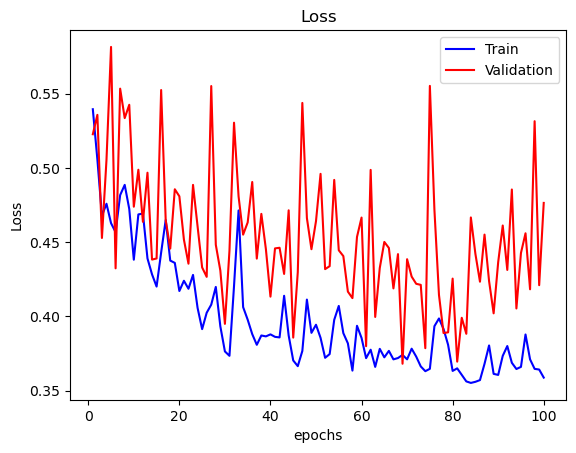

In [285]:
x = np.arange(1,len(train_loss)+1)
plt.plot(x, train_loss, 'b', label='Train')
plt.plot(x, val_loss, 'r', label='Validation')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [286]:
# best validation loss and epoch number of that
best_val_loss = min(val_loss)
best_epoch = x[val_loss.argmin()]
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.36815821131070453
Epoch number of best validation loss is: 69


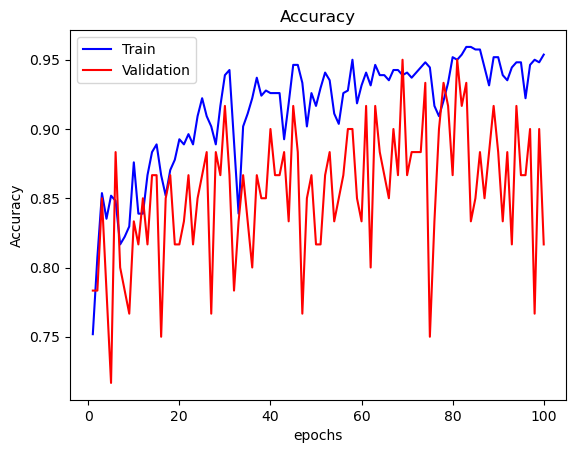

In [287]:
x = np.arange(1,len(train_acc)+1)
plt.plot(x, train_acc, 'b', label='Train')
plt.plot(x, val_acc, 'r', label='Validation')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

In [288]:
# best validation loss and epoch number of that
best_val_acc = max(val_acc)
best_epoch = x[val_acc.argmax()]
print(f'Best validation accuracy is: {best_val_acc}')
print(f'Epoch number of best validation accuracy is: {best_epoch}')

Best validation accuracy is: 0.95
Epoch number of best validation accuracy is: 69


In [289]:
# loading the model parameters trained until best epoch with max accuracy
model.load_state_dict(torch.load('models/model_1.pth'))

<All keys matched successfully>

## Evaluation

In [290]:
model.eval()
actual_labels = []
predicted_labels = []
for i, data in enumerate(test_loader):
    inputs, labels = data[0].expand(-1,3,-1,-1).to(device), data[1].squeeze().to(device)
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    torch.cuda.empty_cache()    
    predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
    predicted_labels.extend(predictions)
    actual_labels.extend(labels.cpu().numpy())

In [291]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[26 12]
 [ 5 97]]
              precision    recall  f1-score   support

           0       0.84      0.68      0.75        38
           1       0.89      0.95      0.92       102

    accuracy                           0.88       140
   macro avg       0.86      0.82      0.84       140
weighted avg       0.88      0.88      0.87       140



<Axes: >

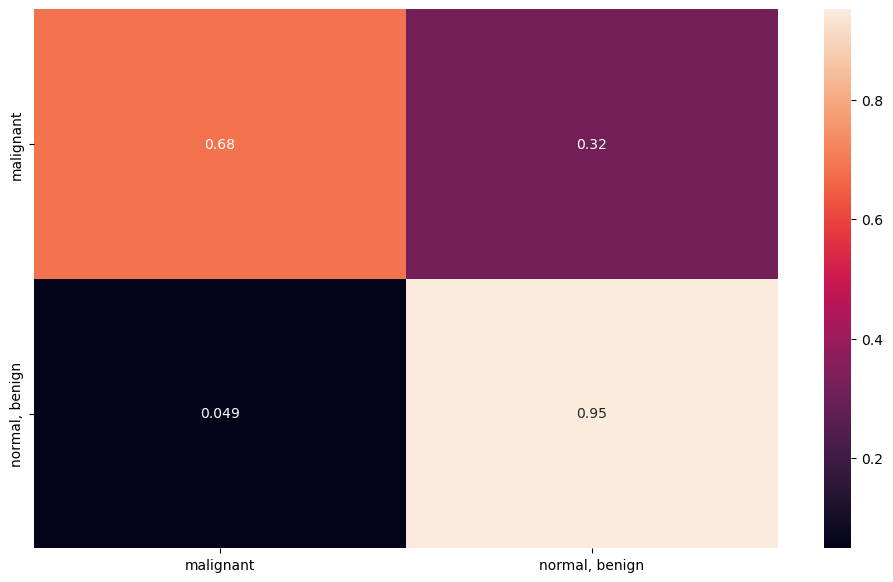

In [292]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['malignant', 'normal, benign'], columns = ['malignant', 'normal, benign'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)

# Conditional DCGAN

## Stabilized (Not In Report, Just a Try)

In [ ]:
# Define the transformation pipelines
torch.manual_seed(40)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize(mean=0.5, std=0.5)
])

In [ ]:
i = 13
print(transform(train_dataset.imgs[i]).mean())
print(transform(train_dataset.imgs[i]).max())
print(transform(train_dataset.imgs[i]).min())
print(transform(train_dataset.imgs[i]).shape)

tensor(-0.3386)
tensor(0.6314)
tensor(-0.8824)
torch.Size([1, 28, 28])


In [ ]:
# Define the custom dataset
torch.manual_seed(40)
train_dataset_forloader = NumpyImageDataset(train_dataset, transform=transform)
val_dataset_forloader = NumpyImageDataset(val_dataset, transform=transform)
test_dataset_forloader = NumpyImageDataset(test_dataset, transform=transform)

# Create a dataloader for the dataset
train_loader = DataLoader(train_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)

In [ ]:
nz = 100
ngf = 128
ndf = 128
nc = 1
nclasses = 2
batch_size = 20

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is a concatenated noise and label vector
            nn.ConvTranspose2d(nz + nclasses, ngf * 8, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # Up-sampling layers
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 3, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 3),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 3, ngf * 2, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 2, 2, 2, bias=True),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is a concatenated image and label vector
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            # Down-sampling layers
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 2, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, 32, 2, 1, 0, bias=True),
            nn.BatchNorm2d(32),
            nn.Sigmoid(),
            nn.Flatten(),
        )
        self.clf = nn.Sequential(nn.Linear(129, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, inp, label):
        x = self.main(inp)
        y = label.unsqueeze(1)
        clf_inp = torch.cat((x, y), dim=1)
        return self.clf(clf_inp)

In [ ]:
torch.cuda.empty_cache()
gc.collect()

16

In [ ]:
device = 'cuda:0'
lr_g = 0.002
lr_d = 0.001

torch.manual_seed(40)
torch.cuda.empty_cache()
gc.collect()
criterion = nn.BCELoss()
generator = Generator().to(device)
discriminator = Discriminator().to(device)
optimizer_g = optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
train_g_loss = np.zeros((0))
train_d_loss = np.zeros((0))
total_epoch_counter = 0
total_epochs = 0

In [341]:
# Train the network
n_epochs = 300
total_epochs += n_epochs
train_g_loss = np.concatenate((train_g_loss, np.zeros((n_epochs))), )
train_d_loss = np.concatenate((train_d_loss, np.zeros((n_epochs))), )

label_fake = torch.full((batch_size,), 0.0, device=device)
label_real = torch.full((batch_size,), 1.0, device=device)
generator.train()
discriminator.train()
torch.cuda.empty_cache()
for epoch in range(n_epochs):
    total_g_loss = 0
    total_d_loss = 0
    
    for i, data in enumerate(train_loader):
        # Update Generator two times in a one step
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator(input_g)
        validity = discriminator(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator(input_g)
        validity = discriminator(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()
        
        # Update Discriminator
        optimizer_d.zero_grad()
        real_imgs = data[0].to(device)
        validity_real = discriminator(real_imgs, data[1].squeeze().to(device, torch.int64))
        err_d_real = criterion(validity_real.view(batch_size), label_real)

        validity_fake = discriminator(imgs_g.detach(), noise_classes)
        err_d_fake = criterion(validity_fake.view(batch_size), label_fake)
        
        err_d = (err_d_real + err_d_fake) / 2
        err_d.backward()
        optimizer_d.step()
        total_d_loss += err_d.item()
                    
    total_g_loss /= len(train_loader)
    total_d_loss /= len(train_loader)
    train_g_loss[total_epoch_counter] = total_g_loss
    train_d_loss[total_epoch_counter] = total_d_loss
    if (total_epoch_counter + 1) % 20 == 0: 
        print('Epoch:[%d/%d] Loss_G: %.4f Loss_D: %.4f'
              % (total_epoch_counter + 1, total_epochs, total_g_loss, total_d_loss))
    total_epoch_counter += 1    

Epoch:[20/300] Loss_G: 2.0782 Loss_D: 0.6150
Epoch:[40/300] Loss_G: 1.5407 Loss_D: 0.6629
Epoch:[60/300] Loss_G: 1.7226 Loss_D: 0.6407
Epoch:[80/300] Loss_G: 1.5804 Loss_D: 0.6628
Epoch:[100/300] Loss_G: 1.6307 Loss_D: 0.6613
Epoch:[120/300] Loss_G: 1.6009 Loss_D: 0.6515
Epoch:[140/300] Loss_G: 1.6463 Loss_D: 0.6616
Epoch:[160/300] Loss_G: 1.7491 Loss_D: 0.6425
Epoch:[180/300] Loss_G: 1.6561 Loss_D: 0.6525
Epoch:[200/300] Loss_G: 2.3904 Loss_D: 0.5802
Epoch:[220/300] Loss_G: 3.5873 Loss_D: 0.4127
Epoch:[240/300] Loss_G: 3.4677 Loss_D: 0.4260
Epoch:[260/300] Loss_G: 4.4383 Loss_D: 0.3169
Epoch:[280/300] Loss_G: 5.0145 Loss_D: 0.2458
Epoch:[300/300] Loss_G: 6.2828 Loss_D: 0.2616


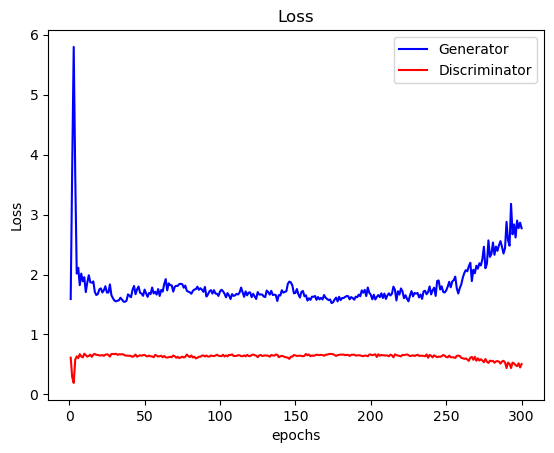

In [30]:
x = np.arange(1,len(train_g_loss)+1)
plt.plot(x, train_g_loss, 'b', label='Generator')
plt.plot(x, train_d_loss, 'r', label='Discriminator')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

## More Stabilized (Reported)

In [108]:
# Define the transformation pipelines
torch.manual_seed(40)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize(mean=0.5, std=0.5)
])

In [109]:
i = 13
print(transform(train_dataset.imgs[i]).mean())
print(transform(train_dataset.imgs[i]).max())
print(transform(train_dataset.imgs[i]).min())
print(transform(train_dataset.imgs[i]).shape)

tensor(-0.3386)
tensor(0.6314)
tensor(-0.8824)
torch.Size([1, 28, 28])


In [111]:
nz = 100
ngf = 128
ndf = 128
nc = 1
nclasses = 2
batch_size = 40

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is a concatenated noise and label vector
            nn.ConvTranspose2d(nz + nclasses, ngf * 8, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # Up-sampling layers
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 3, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 3),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 3, ngf * 2, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 2, 2, 2, bias=True),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is a concatenated image and label vector
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            # Down-sampling layers
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 2, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, 32, 2, 1, 0, bias=True),
            nn.BatchNorm2d(32),
            nn.Sigmoid(),
            nn.Flatten(),
        )
        self.clf = nn.Sequential(nn.Linear(129, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, inp, label):
        x = self.main(inp)
        y = label.unsqueeze(1)
        clf_inp = torch.cat((x, y), dim=1)
        return self.clf(clf_inp)

In [112]:
# Define the custom dataset
torch.manual_seed(40)
train_dataset_forloader = NumpyImageDataset(train_dataset, transform=transform)
val_dataset_forloader = NumpyImageDataset(val_dataset, transform=transform)
test_dataset_forloader = NumpyImageDataset(test_dataset, transform=transform)

# Create a dataloader for the dataset
train_loader = DataLoader(train_dataset_forloader, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset_forloader, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset_forloader, batch_size=batch_size, shuffle=True, drop_last=True)

In [113]:
torch.cuda.empty_cache()
gc.collect()

3878

In [114]:
device = 'cuda:0'
lr_g = 0.002
lr_d = 0.001

torch.manual_seed(40)
torch.cuda.empty_cache()
gc.collect()
criterion = nn.BCELoss()
generator_ms = Generator().to(device)
discriminator_ms = Discriminator().to(device)
optimizer_g = optim.Adam(generator_ms.parameters(), lr=lr_g, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator_ms.parameters(), lr=lr_d, betas=(0.5, 0.999))
train_g_loss = np.zeros((0))
train_d_loss = np.zeros((0))
total_epoch_counter = 0
total_epochs = 0

In [115]:
# Train the network
n_epochs = 1000
total_epochs += n_epochs
train_g_loss = np.concatenate((train_g_loss, np.zeros((n_epochs))), )
train_d_loss = np.concatenate((train_d_loss, np.zeros((n_epochs))), )

label_fake = torch.full((batch_size,), 0.0, device=device)
label_real = torch.full((batch_size,), 1.0, device=device)
generator_ms.train()
discriminator_ms.train()
torch.cuda.empty_cache()
for epoch in range(n_epochs):
    total_g_loss = 0
    total_d_loss = 0
    
    for i, data in enumerate(train_loader):
        # Update Generator two times in a one step
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator_ms(input_g)
        validity = discriminator_ms(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator_ms(input_g)
        validity = discriminator_ms(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator_ms(input_g)
        validity = discriminator_ms(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()
        
        # Update Discriminator
        optimizer_d.zero_grad()
        real_imgs = data[0].to(device)
        validity_real = discriminator_ms(real_imgs, data[1].squeeze().to(device, torch.int64))
        err_d_real = criterion(validity_real.view(batch_size), label_real)

        validity_fake = discriminator_ms(imgs_g.detach(), noise_classes)
        err_d_fake = criterion(validity_fake.view(batch_size), label_fake)
        
        err_d = (err_d_real + err_d_fake) / 2
        err_d.backward()
        optimizer_d.step()
        total_d_loss += err_d.item()
        
    # for i, data in enumerate(train_loader):
    #     optimizer_g.zero_grad()
    #     noise = torch.randn((batch_size, nz, 1, 1), device=device)
    #     noise_classes = torch.randint(0, 2, (batch_size,), device=device)
    #     one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
    #     input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
    #     imgs_g = generator_ms(input_g)
    #     validity = discriminator_ms(imgs_g, noise_classes)
    #     err_g = criterion(validity.view(batch_size), label_real)
    #     err_g.backward()
    #     optimizer_g.step()
    #     total_g_loss += err_g.item()
                    
    total_g_loss /= len(train_loader)
    total_d_loss /= len(train_loader)
    train_g_loss[total_epoch_counter] = total_g_loss
    train_d_loss[total_epoch_counter] = total_d_loss
    if (total_epoch_counter + 1) % 20 == 0: 
        print('Epoch:[%d/%d] Loss_G: %.4f Loss_D: %.4f'
              % (total_epoch_counter + 1, total_epochs, total_g_loss, total_d_loss))
    total_epoch_counter += 1    

Epoch:[20/1000] Loss_G: 1.9861 Loss_D: 0.7604
Epoch:[40/1000] Loss_G: 2.2729 Loss_D: 0.6584
Epoch:[60/1000] Loss_G: 2.3605 Loss_D: 0.6523
Epoch:[80/1000] Loss_G: 2.4220 Loss_D: 0.6637
Epoch:[100/1000] Loss_G: 2.5024 Loss_D: 0.6171
Epoch:[120/1000] Loss_G: 2.4314 Loss_D: 0.6564
Epoch:[140/1000] Loss_G: 2.6894 Loss_D: 0.6562
Epoch:[160/1000] Loss_G: 2.6185 Loss_D: 0.6508
Epoch:[180/1000] Loss_G: 2.4848 Loss_D: 0.6570
Epoch:[200/1000] Loss_G: 2.4617 Loss_D: 0.6562
Epoch:[220/1000] Loss_G: 2.5062 Loss_D: 0.6190
Epoch:[240/1000] Loss_G: 2.4024 Loss_D: 0.6537
Epoch:[260/1000] Loss_G: 2.4169 Loss_D: 0.6384
Epoch:[280/1000] Loss_G: 2.3672 Loss_D: 0.6517
Epoch:[300/1000] Loss_G: 2.4201 Loss_D: 0.6459
Epoch:[320/1000] Loss_G: 2.5217 Loss_D: 0.6598
Epoch:[340/1000] Loss_G: 2.5163 Loss_D: 0.6472
Epoch:[360/1000] Loss_G: 2.5382 Loss_D: 0.6611
Epoch:[380/1000] Loss_G: 2.4205 Loss_D: 0.6768
Epoch:[400/1000] Loss_G: 2.4927 Loss_D: 0.6522
Epoch:[420/1000] Loss_G: 2.6052 Loss_D: 0.6417
Epoch:[440/1000] 

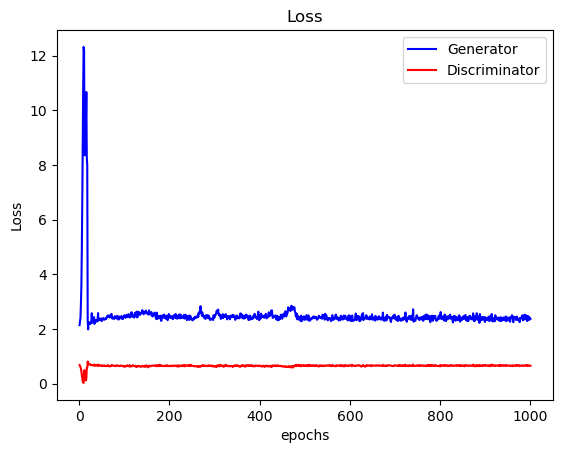

In [116]:
x = np.arange(1,len(train_g_loss)+1)
plt.plot(x, train_g_loss, 'b', label='Generator')
plt.plot(x, train_d_loss, 'r', label='Discriminator')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [117]:
minn = 9999
maxx = -9999
# meann = -9999
for data in train_loader:
    d_min = data[0].min()
    d_max = data[0].max()
    # d_mean = data[0].mean()
    if d_min < minn:
        minn = d_min
    if d_max > maxx:
        maxx = d_max

In [118]:
minn, maxx

(tensor(-1.), tensor(1.))

In [119]:
imgs_g.min(), imgs_g.max()

(tensor(-1., device='cuda:0', grad_fn=<MinBackward1>),
 tensor(0.7487, device='cuda:0', grad_fn=<MaxBackward1>))

In [120]:
# torch.save(generator_ms.state_dict(), 'models/generator_ms.pth')
# torch.save(discriminator_ms.state_dict(), 'models/discriminator_ms.pth')

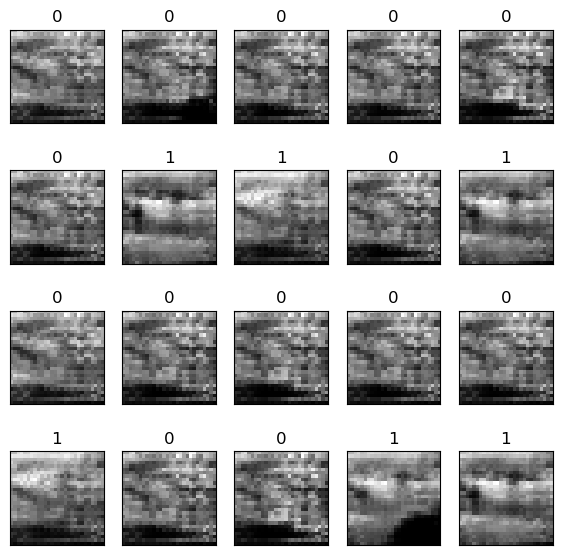

In [121]:
generator_ms.eval()
noise = torch.randn((batch_size, nz, 1, 1), device=device)
noise_classes = torch.randint(0, 2, (batch_size,), device=device)
one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
with torch.no_grad():
    imgs_g = generator_ms(input_g)
fig, axs = plt.subplots(4, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(imgs_g):
        ax.imshow(imgs_g[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title(noise_classes[i].detach().cpu().numpy())
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()


## 4th generation

In [153]:
# Define the transformation pipelines
torch.manual_seed(40)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize(mean=0.5, std=0.5)
])

In [154]:
i = 13
print(transform(train_dataset.imgs[i]).mean())
print(transform(train_dataset.imgs[i]).max())
print(transform(train_dataset.imgs[i]).min())
print(transform(train_dataset.imgs[i]).shape)

tensor(-0.3386)
tensor(0.6314)
tensor(-0.8824)
torch.Size([1, 28, 28])


In [181]:
nz = 100
ngf = 128
ndf = 128
nc = 1
nclasses = 2
batch_size = 40

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.fc = nn.Linear(nz + nclasses, 256)  # Initial fully connected layer

        self.convt_layers = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=2, stride=2, padding=2),
            nn.Tanh(),
        )

        # self.main = nn.Sequential(
            # Input is a concatenated noise and label vector
        #     nn.ConvTranspose2d(nz + nclasses, ngf * 8, 4, 1, 0, bias=True),
        #     nn.BatchNorm2d(ngf * 8),
        #     nn.ReLU(True),
        #     # Up-sampling layers
        #     nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 1, 0, bias=True),
        #     nn.BatchNorm2d(ngf * 4),
        #     nn.ReLU(True),
        #     nn.ConvTranspose2d(ngf * 4, ngf * 3, 4, 1, 0, bias=True),
        #     nn.BatchNorm2d(ngf * 3),
        #     nn.ReLU(True),
        #     nn.ConvTranspose2d(ngf * 3, ngf * 2, 4, 1, 0, bias=True),
        #     nn.BatchNorm2d(ngf * 2),
        #     nn.ReLU(True),
        #     nn.ConvTranspose2d(ngf * 2, ngf, 4, 1, 0, bias=True),
        #     nn.BatchNorm2d(ngf),
        #     nn.ReLU(True),
        #     nn.ConvTranspose2d(ngf, nc, 2, 2, 2, bias=True),
        #     nn.Tanh()
        # )

    def forward(self, inp):
        x = self.fc(inp.squeeze().squeeze())
        x = self.convt_layers(x.view(-1,256,1,1))
        return x

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is a concatenated image and label vector
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            # Down-sampling layers
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 2, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, 32, 2, 1, 0, bias=True),
            nn.BatchNorm2d(32),
            nn.Sigmoid(),
            nn.Flatten(),
        )
        self.clf = nn.Sequential(nn.Linear(129, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, inp, label):
        x = self.main(inp)
        y = label.unsqueeze(1)
        clf_inp = torch.cat((x, y), dim=1)
        return self.clf(clf_inp)

In [182]:
# Define the custom dataset
torch.manual_seed(40)
train_dataset_forloader = NumpyImageDataset(train_dataset, transform=transform)
val_dataset_forloader = NumpyImageDataset(val_dataset, transform=transform)
test_dataset_forloader = NumpyImageDataset(test_dataset, transform=transform)

# Create a dataloader for the dataset
train_loader = DataLoader(train_dataset_forloader, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset_forloader, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset_forloader, batch_size=batch_size, shuffle=True, drop_last=True)

In [183]:
torch.cuda.empty_cache()
gc.collect()

2640

In [209]:
device = 'cuda:0'
lr_g = 0.002
lr_d = 0.001

torch.manual_seed(40)
torch.cuda.empty_cache()
gc.collect()
criterion = nn.BCELoss()
generator_4 = Generator().to(device)
discriminator_4 = Discriminator().to(device)
optimizer_g = optim.Adam(generator_4.parameters(), lr=lr_g, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator_4.parameters(), lr=lr_d, betas=(0.5, 0.999))
train_g_loss = np.zeros((0))
train_d_loss = np.zeros((0))
total_epoch_counter = 0
total_epochs = 0

In [210]:
input_g.view(-1,102,1,1).shape

torch.Size([40, 102, 1, 1])

In [211]:
# Train the network
n_epochs = 500
total_epochs += n_epochs
train_g_loss = np.concatenate((train_g_loss, np.zeros((n_epochs))), )
train_d_loss = np.concatenate((train_d_loss, np.zeros((n_epochs))), )

label_fake = torch.full((batch_size,), 0.0, device=device)
label_real = torch.full((batch_size,), 1.0, device=device)
generator_4.train()
discriminator_4.train()
torch.cuda.empty_cache()
for epoch in range(n_epochs):
    total_g_loss = 0
    total_d_loss = 0
    
    for i, data in enumerate(train_loader):
        # Update Generator two times in a one step
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator_4(input_g)
        validity = discriminator_4(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator_4(input_g)
        validity = discriminator_4(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator_4(input_g)
        validity = discriminator_4(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()
        
        # Update Discriminator
        optimizer_d.zero_grad()
        real_imgs = data[0].to(device)
        validity_real = discriminator_4(real_imgs, data[1].squeeze().to(device, torch.int64))
        err_d_real = criterion(validity_real.view(batch_size), label_real)

        validity_fake = discriminator_4(imgs_g.detach(), noise_classes)
        err_d_fake = criterion(validity_fake.view(batch_size), label_fake)
        
        err_d = (err_d_real + err_d_fake) / 2
        err_d.backward()
        optimizer_d.step()
        total_d_loss += err_d.item()
        
    # for i, data in enumerate(train_loader):
    #     optimizer_g.zero_grad()
    #     noise = torch.randn((batch_size, nz, 1, 1), device=device)
    #     noise_classes = torch.randint(0, 2, (batch_size,), device=device)
    #     one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
    #     input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
    #     imgs_g = generator_4(input_g)
    #     validity = discriminator_4(imgs_g, noise_classes)
    #     err_g = criterion(validity.view(batch_size), label_real)
    #     err_g.backward()
    #     optimizer_g.step()
    #     total_g_loss += err_g.item()
                    
    total_g_loss /= len(train_loader)
    total_d_loss /= len(train_loader)
    train_g_loss[total_epoch_counter] = total_g_loss
    train_d_loss[total_epoch_counter] = total_d_loss
    if (total_epoch_counter + 1) % 20 == 0: 
        print('Epoch:[%d/%d] Loss_G: %.4f Loss_D: %.4f'
              % (total_epoch_counter + 1, total_epochs, total_g_loss, total_d_loss))
    total_epoch_counter += 1    

Epoch:[20/500] Loss_G: 2.3242 Loss_D: 0.6713
Epoch:[40/500] Loss_G: 2.3604 Loss_D: 0.6672
Epoch:[60/500] Loss_G: 2.3490 Loss_D: 0.6680
Epoch:[80/500] Loss_G: 2.3910 Loss_D: 0.6423
Epoch:[100/500] Loss_G: 2.4315 Loss_D: 0.6626
Epoch:[120/500] Loss_G: 2.3228 Loss_D: 0.6711
Epoch:[140/500] Loss_G: 2.4016 Loss_D: 0.6723
Epoch:[160/500] Loss_G: 2.3645 Loss_D: 0.6640
Epoch:[180/500] Loss_G: 2.4234 Loss_D: 0.6678
Epoch:[200/500] Loss_G: 2.3996 Loss_D: 0.6653
Epoch:[220/500] Loss_G: 2.3815 Loss_D: 0.6472
Epoch:[240/500] Loss_G: 2.3777 Loss_D: 0.6591
Epoch:[260/500] Loss_G: 2.3496 Loss_D: 0.6682
Epoch:[280/500] Loss_G: 2.4174 Loss_D: 0.6577
Epoch:[300/500] Loss_G: 2.4482 Loss_D: 0.6575
Epoch:[320/500] Loss_G: 2.4954 Loss_D: 0.6728
Epoch:[340/500] Loss_G: 2.4021 Loss_D: 0.6700
Epoch:[360/500] Loss_G: 2.3346 Loss_D: 0.6508
Epoch:[380/500] Loss_G: 2.4328 Loss_D: 0.6634
Epoch:[400/500] Loss_G: 2.4475 Loss_D: 0.6762
Epoch:[420/500] Loss_G: 2.3896 Loss_D: 0.6681
Epoch:[440/500] Loss_G: 2.3947 Loss_D:

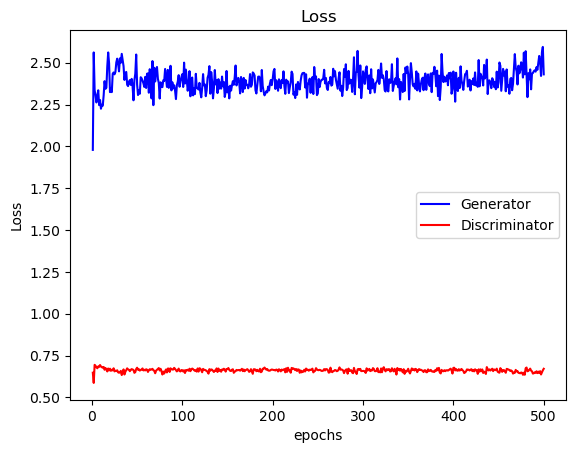

In [212]:
x = np.arange(1,len(train_g_loss)+1)
plt.plot(x, train_g_loss, 'b', label='Generator')
plt.plot(x, train_d_loss, 'r', label='Discriminator')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [213]:
minn = 9999
maxx = -9999
# meann = -9999
for data in train_loader:
    d_min = data[0].min()
    d_max = data[0].max()
    # d_mean = data[0].mean()
    if d_min < minn:
        minn = d_min
    if d_max > maxx:
        maxx = d_max

In [214]:
minn, maxx

(tensor(-1.), tensor(1.))

In [215]:
imgs_g.min(), imgs_g.max()

(tensor(-0.9942, device='cuda:0', grad_fn=<MinBackward1>),
 tensor(0.9804, device='cuda:0', grad_fn=<MaxBackward1>))

In [216]:
# torch.save(generator_4.state_dict(), 'models/generator_4.pth')
# torch.save(discriminator_4.state_dict(), 'models/discriminator_4.pth')

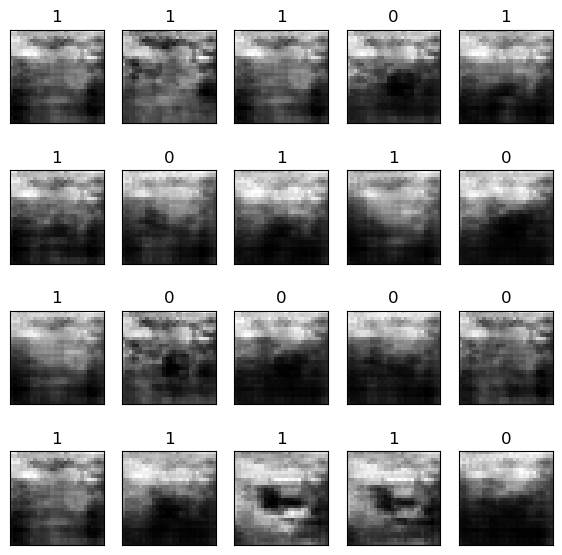

In [217]:
generator_4.eval()
noise = torch.randn((batch_size, nz, 1, 1), device=device)
noise_classes = torch.randint(0, 2, (batch_size,), device=device)
one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
with torch.no_grad():
    imgs_g = generator_4(input_g)
fig, axs = plt.subplots(4, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(imgs_g):
        ax.imshow(imgs_g[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title(noise_classes[i].detach().cpu().numpy())
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()


## Non-Stable Training

In [63]:
device = 'cuda:0'
lr = 0.0002

torch.manual_seed(40)
torch.cuda.empty_cache()
gc.collect()
criterion = nn.BCELoss()
generator_ns = Generator().to(device)
discriminator_ns = Discriminator().to(device)
optimizer_g = optim.Adam(generator_ns.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator_ns.parameters(), lr=lr, betas=(0.5, 0.999))
train_g_loss_ns = np.zeros((0))
train_d_loss_ns = np.zeros((0))
total_epoch_counter = 0
total_epochs = 0

In [64]:
# Train the network
n_epochs = 300
total_epochs += n_epochs
train_g_loss_ns = np.concatenate((train_g_loss_ns, np.zeros((n_epochs))), )
train_d_loss_ns = np.concatenate((train_d_loss_ns, np.zeros((n_epochs))), )

label_fake = torch.full((batch_size,), 0.0, device=device)
label_real = torch.full((batch_size,), 1.0, device=device)
generator_ns.train()
discriminator_ns.train()
torch.cuda.empty_cache()
for epoch in range(n_epochs):
    total_g_loss = 0
    total_d_loss = 0
    
    for i, data in enumerate(train_loader):
        # Update Generator two times in a one step
        
        optimizer_g.zero_grad()
        noise = torch.randn((batch_size, nz, 1, 1), device=device)
        noise_classes = torch.randint(0, 2, (batch_size,), device=device)
        one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
        input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
        imgs_g = generator_ns(input_g)
        validity = discriminator_ns(imgs_g, noise_classes)
        err_g = criterion(validity.view(batch_size), label_real)
        err_g.backward()
        optimizer_g.step()
        total_g_loss += err_g.item()

        # Update Discriminator
        optimizer_d.zero_grad()
        real_imgs = data[0].to(device)
        validity_real = discriminator_ns(real_imgs, data[1].squeeze().to(device, torch.int64))
        err_d_real = criterion(validity_real.view(batch_size), label_real)

        validity_fake = discriminator_ns(imgs_g.detach(), noise_classes)
        err_d_fake = criterion(validity_fake.view(batch_size), label_fake)
        
        err_d = (err_d_real + err_d_fake) / 2
        err_d.backward()
        optimizer_d.step()
        total_d_loss += err_d.item()
                    
    total_g_loss /= len(train_loader)
    total_d_loss /= len(train_loader)
    train_g_loss_ns[total_epoch_counter] = total_g_loss
    train_d_loss_ns[total_epoch_counter] = total_d_loss
    if (total_epoch_counter + 1) % 20 == 0: 
        print('Epoch:[%d/%d] Loss_G: %.4f Loss_D: %.4f'
              % (total_epoch_counter + 1, total_epochs, total_g_loss, total_d_loss))
    total_epoch_counter += 1    

Epoch:[20/300] Loss_G: 2.0520 Loss_D: 0.3381
Epoch:[40/300] Loss_G: 2.0719 Loss_D: 0.3831
Epoch:[60/300] Loss_G: 2.0749 Loss_D: 0.2797
Epoch:[80/300] Loss_G: 2.3615 Loss_D: 0.3292
Epoch:[100/300] Loss_G: 2.0041 Loss_D: 0.3086
Epoch:[120/300] Loss_G: 2.1291 Loss_D: 0.3044
Epoch:[140/300] Loss_G: 2.5104 Loss_D: 0.2639
Epoch:[160/300] Loss_G: 3.1876 Loss_D: 0.1814
Epoch:[180/300] Loss_G: 3.1669 Loss_D: 0.1647
Epoch:[200/300] Loss_G: 3.0762 Loss_D: 0.1828
Epoch:[220/300] Loss_G: 3.6076 Loss_D: 0.1610
Epoch:[240/300] Loss_G: 3.9965 Loss_D: 0.1751
Epoch:[260/300] Loss_G: 4.5446 Loss_D: 0.1772
Epoch:[280/300] Loss_G: 3.9357 Loss_D: 0.1125
Epoch:[300/300] Loss_G: 5.6325 Loss_D: 0.1751


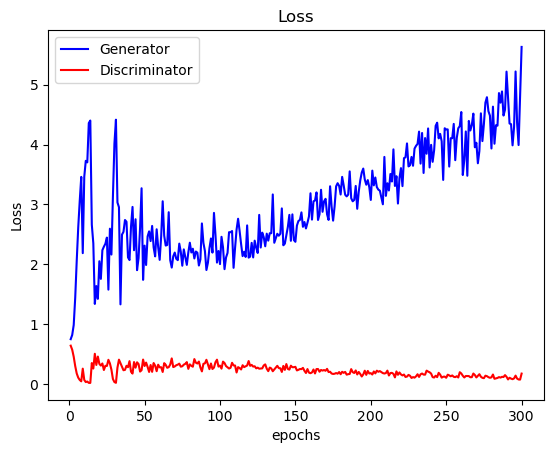

In [65]:
# Non-Stabel Loss
x = np.arange(1,len(train_g_loss_ns)+1)
plt.plot(x, train_g_loss_ns, 'b', label='Generator')
plt.plot(x, train_d_loss_ns, 'r', label='Discriminator')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

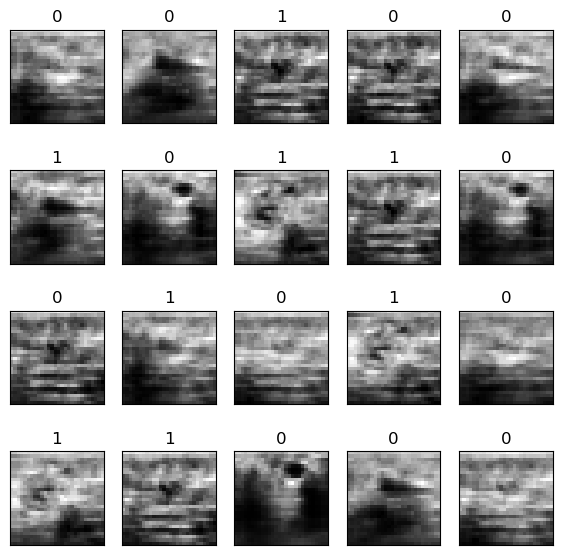

In [71]:
generator.eval()
noise = torch.randn((batch_size, nz, 1, 1), device=device)
noise_classes = torch.randint(0, 2, (batch_size,), device=device)
one_hot_labels_fake = torch.zeros(batch_size, nclasses, device=device).scatter_(1, noise_classes.view(batch_size, 1), 1)
input_g = torch.cat((noise, one_hot_labels_fake.unsqueeze(2).unsqueeze(3)),dim=1)
with torch.no_grad():
    imgs_g = generator(input_g)
fig, axs = plt.subplots(4, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(imgs_g):
        ax.imshow(imgs_g[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title(noise_classes[i].detach().cpu().numpy())
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()


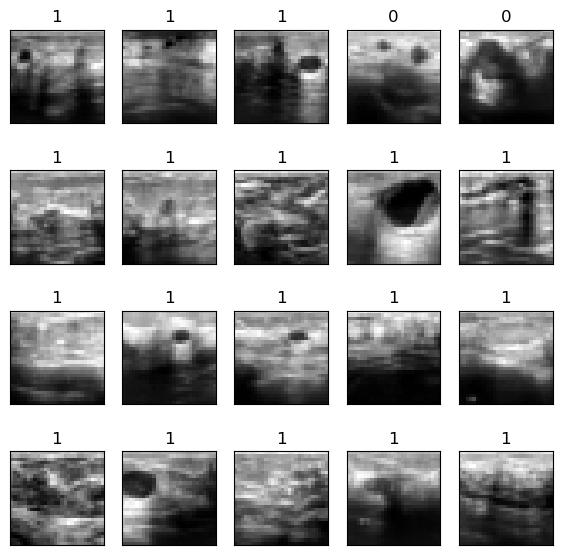

In [32]:
fig, axs = plt.subplots(4, 5, figsize=(7, 7))

# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(imgs_g):
        ax.imshow(real_imgs[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title(data[1][i].squeeze().cpu().numpy())
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()


## 2000 Samples of each class

In [218]:
torch.cuda.empty_cache()
gc.collect()

43307

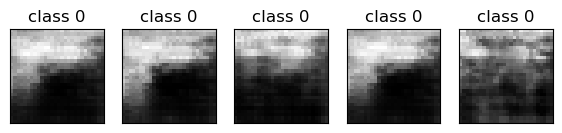

In [219]:
torch.cuda.empty_cache()
gc.collect()
generator_4.eval()
total_imgs_g_cls0 = torch.zeros((0, 1, 28, 28), device=device)
for i in range(20):
    torch.cuda.empty_cache()
    gc.collect()
    noise_cls0 = torch.randn((100, nz, 1, 1), device=device)
    label_cls0 = torch.tensor([[1,0]], device=device)
    input_g_cls0 = torch.cat((noise_cls0, label_cls0.repeat(100,1).unsqueeze(2).unsqueeze(3)),dim=1)
    with torch.no_grad():
        imgs_g_cls0 = generator_4(input_g_cls0)
    total_imgs_g_cls0 = torch.cat((total_imgs_g_cls0, imgs_g_cls0), dim=0)
fig, axs = plt.subplots(1, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(total_imgs_g_cls0):
        ax.imshow(total_imgs_g_cls0[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title('class 0')
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

In [220]:
torch.cuda.empty_cache()
gc.collect()

39342

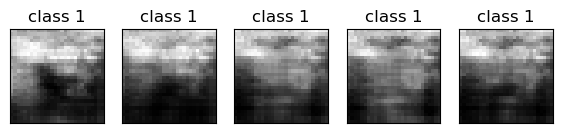

In [221]:
torch.cuda.empty_cache()
gc.collect()
generator_4.eval()
total_imgs_g_cls1 = torch.zeros((0, 1, 28, 28), device=device)
for i in range(20):
    torch.cuda.empty_cache()
    gc.collect()
    noise_cls1 = torch.randn((100, nz, 1, 1), device=device)
    label_cls1 = torch.tensor([[0,1]], device=device)
    input_g_cls1 = torch.cat((noise_cls1, label_cls1.repeat(100,1).unsqueeze(2).unsqueeze(3)),dim=1)
    with torch.no_grad():
        imgs_g_cls1 = generator_4(input_g_cls1)
    total_imgs_g_cls1 = torch.cat((total_imgs_g_cls1, imgs_g_cls1), dim=0)
fig, axs = plt.subplots(1, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(total_imgs_g_cls1):
        ax.imshow(total_imgs_g_cls1[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title('class 1')
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

# Mix fake and real datasets

## 4th

In [222]:
train_dataset

Dataset BreastMNIST (breastmnist)
    Number of datapoints: 546
    Root location: /home/sajad/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0

In [223]:
mix_dataset_imgs = np.concatenate((train_dataset.imgs, 
                              total_imgs_g_cls0.squeeze(1).cpu().numpy(), 
                              total_imgs_g_cls1.squeeze(1).cpu().numpy()))
mix_dataset_lbs = np.concatenate((train_dataset.labels,
                                 np.array([[0]]).repeat(2000,0),
                                 np.array([[1]]).repeat(2000,0)))

In [224]:
mix_dataset_imgs.shape, mix_dataset_lbs.shape, mix_dataset_lbs[mix_dataset_lbs[:,0] == 0].shape, mix_dataset_lbs[mix_dataset_lbs[:,0] == 1].shape

((4546, 28, 28), (4546, 1), (2147, 1), (2399, 1))

In [225]:
num_each_cls = 500
cls0_inds = np.random.randint(0, 2147, num_each_cls)
cls1_inds = np.random.randint(0, 2399, num_each_cls)
data_cls0 = mix_dataset_imgs[mix_dataset_lbs[:,0] == 0][cls0_inds]
data_cls1 = mix_dataset_imgs[mix_dataset_lbs[:,0] == 1][cls1_inds]
data_img_eq_cls = np.concatenate((data_cls0, data_cls1))
data_lbs_eq_cls = np.concatenate((np.array([[0]]).repeat(num_each_cls,0),
                                  np.array([[1]]).repeat(num_each_cls,0)))

In [226]:
data_cls0.shape, data_cls1.shape, data_img_eq_cls.shape, data_lbs_eq_cls.shape

((500, 28, 28), (500, 28, 28), (1000, 28, 28), (1000, 1))

In [227]:
# Define a custom dataset class that loads image data from numpy arrays
class NumpyImageDataset(Dataset):
    def __init__(self, image_data_np, transform):
        self.image_data_np = image_data_np.imgs
        self.labels = image_data_np.labels
        self.transform = transform

    def __len__(self):
        return len(self.image_data_np)

    def __getitem__(self, index):
        image_data = self.image_data_np[index]
        label = self.labels[index]
        transformed_tensor = self.transform(image_data)
        return (transformed_tensor, label)
    
class MixImageDataset(Dataset):
    def __init__(self, image_data_np, labels, transform):
        self.image_data_np = image_data_np
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_data_np)

    def __getitem__(self, index):
        image_data = self.image_data_np[index]
        label = self.labels[index]
        transformed_tensor = self.transform(image_data)
        return (transformed_tensor, label)

In [228]:
# Define the transformation pipelines
torch.manual_seed(40)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=0.5, std=0.5),
])

In [229]:
# Define the custom dataset
torch.manual_seed(40)
train_dataset_forloader = MixImageDataset(data_img_eq_cls, data_lbs_eq_cls, transform=transform)
val_dataset_forloader = NumpyImageDataset(val_dataset, transform=transform)
test_dataset_forloader = NumpyImageDataset(test_dataset, transform=transform)

# Create a dataloader for the dataset
train_loader_p3 = DataLoader(train_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
val_loader_p3 = DataLoader(val_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
test_loader_p3 = DataLoader(test_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)

In [230]:
def train(model, trainloader, criterion, optimizer, device):
    model.train()
    actual_labels = []
    predicted_labels = []
    running_loss = 0.0
    for i, data in enumerate(trainloader):
        inputs, labels = data[0].expand(-1,3,-1,-1).to(device), data[1].squeeze().to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        torch.cuda.empty_cache()
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    accuracy = (np.array(predicted_labels) == np.array(actual_labels)).sum() / len(predicted_labels)
    return running_loss / len(trainloader), accuracy

In [231]:
def validate(model, val_loader, criterion, device):
    model.eval()
    actual_labels = []
    predicted_labels = []
    total_loss = 0.0
    num_batches = 0
    for i, data in enumerate(val_loader):
        inputs, labels = data[0].expand(-1,3,-1,-1).to(device), data[1].squeeze().to(device)
        with torch.no_grad():
            outputs = model(inputs)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        torch.cuda.empty_cache()    
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    accuracy = (np.array(predicted_labels) == np.array(actual_labels)).sum() / len(predicted_labels)
    return total_loss / len(val_loader), accuracy

In [136]:
gc.collect()
torch.cuda.empty_cache()

In [232]:
device = 'cuda:0'
lr = 0.001

# Initialize the model and the optimizer
torch.manual_seed(40)
model_p3 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model_p3.fc = nn.Sequential(nn.Linear(2048, 2),
                         nn.Softmax(dim=-1),)
model_p3 = model_p3.to(device)
optimizer = optim.Adam(model_p3.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
total_epoch_counter = 0
total_epochs = 0
best_val_acc = 0

In [233]:
num_epochs = 50
total_epochs += num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    # train for one epoch
    tmp_train = train(model_p3, train_loader_p3, criterion, optimizer, device)
    train_loss[total_epoch_counter], train_acc[total_epoch_counter] = tmp_train
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_val = validate(model_p3, val_loader_p3, criterion, device)
    val_loss[total_epoch_counter], val_acc[total_epoch_counter] = tmp_val
    # print the results for this epoch
    print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.5f}, Val loss: {:.4f}, Val acc: {:.4f}'
           .format(total_epoch_counter+1, total_epochs, train_loss[total_epoch_counter], lr,
                   val_loss[total_epoch_counter], val_acc[total_epoch_counter]))
    if val_acc[total_epoch_counter] >= best_val_acc:
        best_val_acc = val_acc[total_epoch_counter]
        torch.save(model_p3.state_dict(), f'models/model_res_4th_{total_epoch_counter}.pth')
        print('Model saved.')
    total_epoch_counter += 1

Train. Epoch [1/50], Train loss: 0.6130, lr: 0.00100, Val loss: 0.8068, Val acc: 0.4833
Model saved.
Train. Epoch [2/50], Train loss: 0.5228, lr: 0.00100, Val loss: 1.0609, Val acc: 0.2500
Train. Epoch [3/50], Train loss: 0.4168, lr: 0.00100, Val loss: 0.6171, Val acc: 0.7000
Model saved.
Train. Epoch [4/50], Train loss: 0.3978, lr: 0.00100, Val loss: 0.5633, Val acc: 0.7500
Model saved.
Train. Epoch [5/50], Train loss: 0.3798, lr: 0.00100, Val loss: 0.5966, Val acc: 0.7167
Train. Epoch [6/50], Train loss: 0.3850, lr: 0.00100, Val loss: 0.5466, Val acc: 0.7667
Model saved.
Train. Epoch [7/50], Train loss: 0.3905, lr: 0.00100, Val loss: 0.5466, Val acc: 0.7667
Model saved.
Train. Epoch [8/50], Train loss: 0.3698, lr: 0.00100, Val loss: 0.9475, Val acc: 0.2333
Train. Epoch [9/50], Train loss: 0.3648, lr: 0.00100, Val loss: 1.0466, Val acc: 0.2667
Train. Epoch [10/50], Train loss: 0.3648, lr: 0.00100, Val loss: 1.0466, Val acc: 0.2667
Train. Epoch [11/50], Train loss: 0.3678, lr: 0.00100,

In [146]:
# torch.save(model_p3.state_dict(), 'models/model_p3_final_epoch.pth')


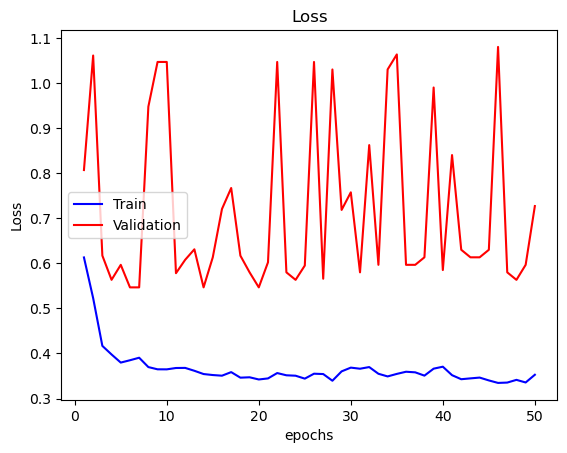

In [234]:
x = np.arange(1,len(train_loss)+1)
plt.plot(x, train_loss, 'b', label='Train')
plt.plot(x, val_loss, 'r', label='Validation')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [235]:
# best validation loss and epoch number of that
best_val_loss = min(val_loss)
best_epoch = x[val_loss.argmin()]
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.5465952157974243
Epoch number of best validation loss is: 6


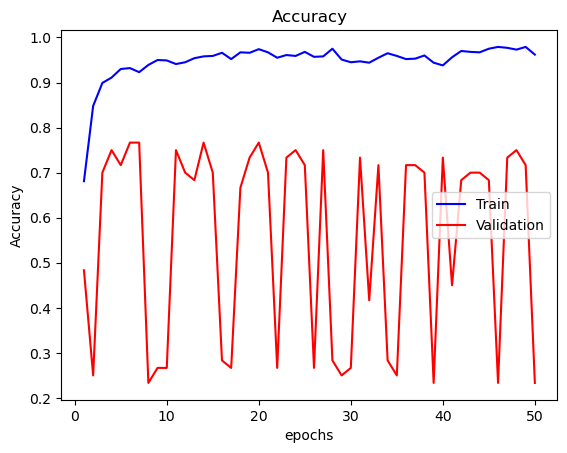

In [236]:
x = np.arange(1,len(train_acc)+1)
plt.plot(x, train_acc, 'b', label='Train')
plt.plot(x, val_acc, 'r', label='Validation')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

In [237]:
# best validation loss and epoch number of that
best_val_acc = max(val_acc)
best_epoch = x[val_acc.argmax()]
print(f'Best validation accuracy is: {best_val_acc}')
print(f'Epoch number of best validation accuracy is: {best_epoch}')

Best validation accuracy is: 0.7666666666666667
Epoch number of best validation accuracy is: 6


In [240]:
# loading the model parameters trained until best epoch with max accuracy
model_p3.load_state_dict(torch.load('models/model_res_4th_19.pth'))

<All keys matched successfully>

## Evaluation MS

In [241]:
model_p3.eval()
actual_labels = []
predicted_labels = []
for i, data in enumerate(test_loader):
    inputs, labels = data[0].expand(-1,3,-1,-1).to(device), data[1].squeeze().to(device)
    with torch.no_grad():
        outputs = model_p3(inputs)
    loss = criterion(outputs, labels)
    torch.cuda.empty_cache()    
    predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
    predicted_labels.extend(predictions)
    actual_labels.extend(labels.cpu().numpy())

In [242]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[32  0]
 [88  0]]
              precision    recall  f1-score   support

           0       0.27      1.00      0.42        32
           1       0.00      0.00      0.00        88

    accuracy                           0.27       120
   macro avg       0.13      0.50      0.21       120
weighted avg       0.07      0.27      0.11       120



/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Axes: >

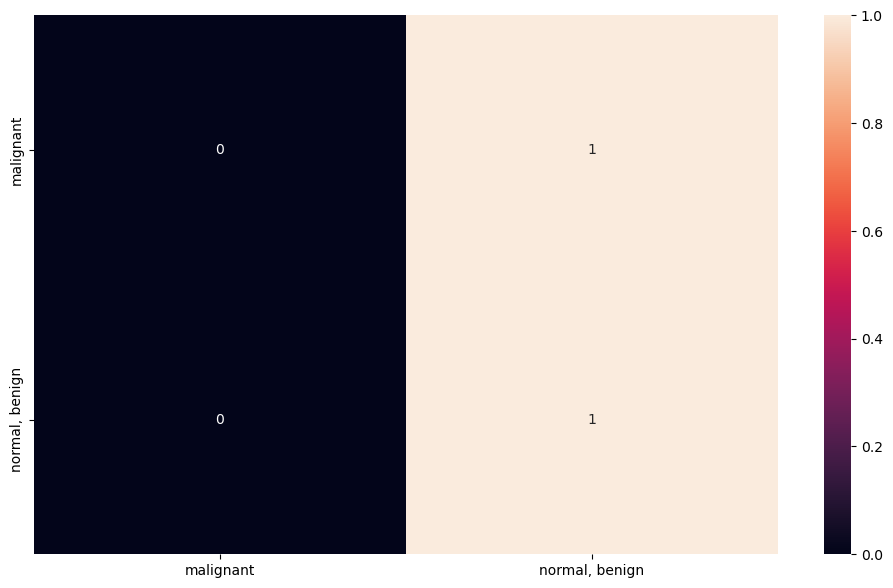

In [150]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['malignant', 'normal, benign'], columns = ['malignant', 'normal, benign'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)

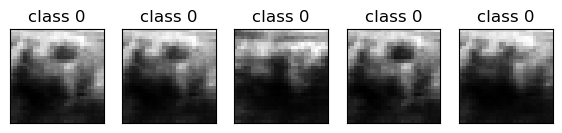

In [343]:
torch.cuda.empty_cache()
gc.collect()
generator.eval()
total_imgs_g_cls0 = torch.zeros((0, 1, 28, 28), device=device)
for i in range(20):
    torch.cuda.empty_cache()
    gc.collect()
    noise_cls0 = torch.randn((100, nz, 1, 1), device=device)
    label_cls0 = torch.tensor([[1,0]], device=device)
    input_g_cls0 = torch.cat((noise_cls0, label_cls0.repeat(100,1).unsqueeze(2).unsqueeze(3)),dim=1)
    with torch.no_grad():
        imgs_g_cls0 = generator(input_g_cls0)
    total_imgs_g_cls0 = torch.cat((total_imgs_g_cls0, imgs_g_cls0), dim=0)
fig, axs = plt.subplots(1, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(total_imgs_g_cls0):
        ax.imshow(total_imgs_g_cls0[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title('class 0')
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

In [344]:
torch.cuda.empty_cache()
gc.collect()

9957

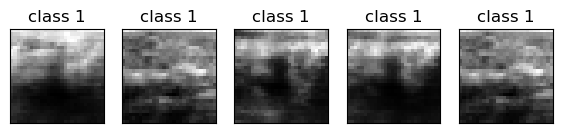

In [345]:
torch.cuda.empty_cache()
gc.collect()
generator.eval()
total_imgs_g_cls1 = torch.zeros((0, 1, 28, 28), device=device)
for i in range(20):
    torch.cuda.empty_cache()
    gc.collect()
    noise_cls1 = torch.randn((100, nz, 1, 1), device=device)
    label_cls1 = torch.tensor([[0,1]], device=device)
    input_g_cls1 = torch.cat((noise_cls1, label_cls1.repeat(100,1).unsqueeze(2).unsqueeze(3)),dim=1)
    with torch.no_grad():
        imgs_g_cls1 = generator(input_g_cls1)
    total_imgs_g_cls1 = torch.cat((total_imgs_g_cls1, imgs_g_cls1), dim=0)
fig, axs = plt.subplots(1, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(total_imgs_g_cls1):
        ax.imshow(total_imgs_g_cls1[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title('class 1')
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

In [346]:
mix_dataset_imgs = np.concatenate((train_dataset.imgs, 
                              total_imgs_g_cls0.squeeze(1).cpu().numpy(), 
                              total_imgs_g_cls1.squeeze(1).cpu().numpy()))
mix_dataset_lbs = np.concatenate((train_dataset.labels,
                                 np.array([[0]]).repeat(2000,0),
                                 np.array([[1]]).repeat(2000,0)))

In [347]:
num_each_cls = 500
cls0_inds = np.random.randint(0, 2147, num_each_cls)
cls1_inds = np.random.randint(0, 2399, num_each_cls)
data_cls0 = mix_dataset_imgs[mix_dataset_lbs[:,0] == 0][cls0_inds]
data_cls1 = mix_dataset_imgs[mix_dataset_lbs[:,0] == 1][cls1_inds]
data_img_eq_cls = np.concatenate((data_cls0, data_cls1))
data_lbs_eq_cls = np.concatenate((np.array([[0]]).repeat(num_each_cls,0),
                                  np.array([[1]]).repeat(num_each_cls,0)))

In [318]:
# Define a custom dataset class that loads image data from numpy arrays
class NumpyImageDataset(Dataset):
    def __init__(self, image_data_np, transform):
        self.image_data_np = image_data_np.imgs
        self.labels = image_data_np.labels
        self.transform = transform

    def __len__(self):
        return len(self.image_data_np)

    def __getitem__(self, index):
        image_data = self.image_data_np[index]
        label = self.labels[index]
        transformed_tensor = self.transform(image_data)
        return (transformed_tensor, label)
    
class MixImageDataset(Dataset):
    def __init__(self, image_data_np, labels, transform):
        self.image_data_np = image_data_np
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_data_np)

    def __getitem__(self, index):
        image_data = self.image_data_np[index]
        label = self.labels[index]
        transformed_tensor = self.transform(image_data)
        return (transformed_tensor, label)

In [350]:
# Define the transformation pipelines
torch.manual_seed(40)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=0.5, std=0.5),
])

In [351]:
# Define the custom dataset
torch.manual_seed(40)
train_dataset_forloader = MixImageDataset(data_img_eq_cls, data_lbs_eq_cls, transform=transform)
val_dataset_forloader = NumpyImageDataset(val_dataset, transform=transform)
test_dataset_forloader = NumpyImageDataset(test_dataset, transform=transform)

# Create a dataloader for the dataset
train_loader_p3_t = DataLoader(train_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
val_loader_p3_t = DataLoader(val_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
test_loader_p3_t = DataLoader(test_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)

In [352]:
gc.collect()
torch.cuda.empty_cache()

In [353]:
device = 'cuda:0'
lr = 0.001

# Initialize the model and the optimizer
torch.manual_seed(40)
model_p3_t = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model_p3_t.fc = nn.Sequential(nn.Linear(2048, 2),
                         nn.Softmax(dim=-1),)
model_p3_t = model_p3_t.to(device)
optimizer = optim.Adam(model_p3_t.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
total_epoch_counter = 0
total_epochs = 0
best_val_acc = 0

In [354]:
num_epochs = 50
total_epochs += num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    # train for one epoch
    tmp_train = train(model_p3_t, train_loader_p3_t, criterion, optimizer, device)
    train_loss[total_epoch_counter], train_acc[total_epoch_counter] = tmp_train
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_val = validate(model_p3_t, val_loader_p3_t, criterion, device)
    val_loss[total_epoch_counter], val_acc[total_epoch_counter] = tmp_val
    # print the results for this epoch
    print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.5f}, Val loss: {:.4f}, Val acc: {:.4f}'
           .format(total_epoch_counter+1, total_epochs, train_loss[total_epoch_counter], lr,
                   val_loss[total_epoch_counter], val_acc[total_epoch_counter]))
    if val_acc[total_epoch_counter] >= best_val_acc:
        best_val_acc = val_acc[total_epoch_counter]
        torch.save(model_p3_t.state_dict(), f'models/model_p3_t.pth')
        print('Model saved.')
    total_epoch_counter += 1

Train. Epoch [1/50], Train loss: 0.6892, lr: 0.00100, Val loss: 0.7000, Val acc: 0.2500
Model saved.
Train. Epoch [2/50], Train loss: 0.6798, lr: 0.00100, Val loss: 0.7019, Val acc: 0.2500
Train. Epoch [3/50], Train loss: 0.6771, lr: 0.00100, Val loss: 0.7023, Val acc: 0.3000
Model saved.
Train. Epoch [4/50], Train loss: 0.6789, lr: 0.00100, Val loss: 0.7064, Val acc: 0.2500
Train. Epoch [5/50], Train loss: 0.6777, lr: 0.00100, Val loss: 0.7069, Val acc: 0.2833
Train. Epoch [6/50], Train loss: 0.6830, lr: 0.00100, Val loss: 0.7112, Val acc: 0.2333
Train. Epoch [7/50], Train loss: 0.6805, lr: 0.00100, Val loss: 0.7115, Val acc: 0.2333
Train. Epoch [8/50], Train loss: 0.6677, lr: 0.00100, Val loss: 0.7148, Val acc: 0.2333
Train. Epoch [9/50], Train loss: 0.6374, lr: 0.00100, Val loss: 0.7079, Val acc: 0.2667
Train. Epoch [10/50], Train loss: 0.5735, lr: 0.00100, Val loss: 1.0466, Val acc: 0.2667
Train. Epoch [11/50], Train loss: 0.5676, lr: 0.00100, Val loss: 0.6852, Val acc: 0.7500
Mode

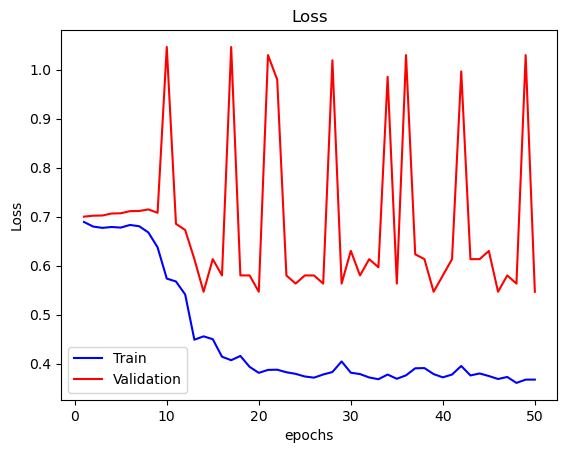

In [358]:
x = np.arange(1,len(train_loss)+1)
plt.plot(x, train_loss, 'b', label='Train')
plt.plot(x, val_loss, 'r', label='Validation')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [359]:
# best validation loss and epoch number of that
best_val_loss = min(val_loss)
best_epoch = x[val_loss.argmin()]
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.5465951164563497
Epoch number of best validation loss is: 50


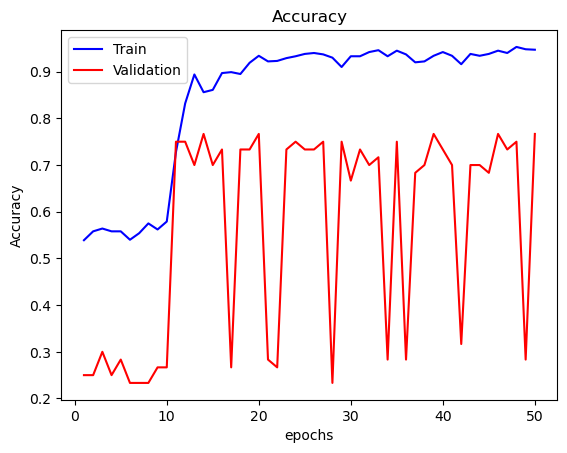

In [360]:
x = np.arange(1,len(train_acc)+1)
plt.plot(x, train_acc, 'b', label='Train')
plt.plot(x, val_acc, 'r', label='Validation')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

In [361]:
# best validation loss and epoch number of that
best_val_acc = max(val_acc)
best_epoch = x[val_acc.argmax()]
print(f'Best validation accuracy is: {best_val_acc}')
print(f'Epoch number of best validation accuracy is: {best_epoch}')

Best validation accuracy is: 0.7666666666666667
Epoch number of best validation accuracy is: 14


In [363]:
# torch.save(model_p3_t.state_dict(), f'models/model_p3_t_ch2.pth')

In [369]:
# loading the model parameters trained until best epoch with max accuracy
model_p3_t.load_state_dict(torch.load('models/model_p3_t_1.pth'))

<All keys matched successfully>

In [370]:
model_p3_t.eval()
actual_labels = []
predicted_labels = []
for i, data in enumerate(test_loader_p3_t):
    inputs, labels = data[0].expand(-1,3,-1,-1).to(device), data[1].squeeze().to(device)
    with torch.no_grad():
        outputs = model_p3_t(inputs)
    loss = criterion(outputs, labels)
    torch.cuda.empty_cache()    
    predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
    predicted_labels.extend(predictions)
    actual_labels.extend(labels.cpu().numpy())

In [371]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[  0  40]
 [  0 100]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.71      1.00      0.83       100

    accuracy                           0.71       140
   macro avg       0.36      0.50      0.42       140
weighted avg       0.51      0.71      0.60       140



/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Axes: >

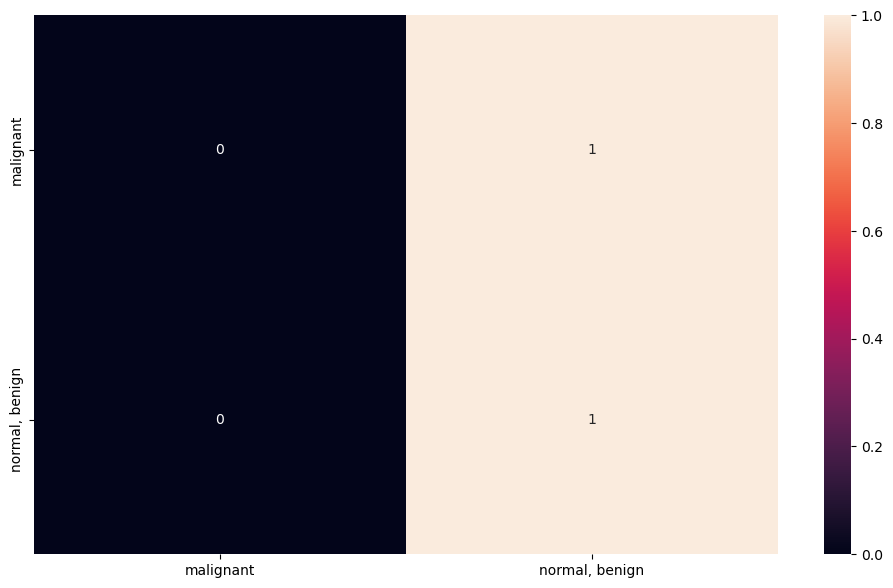

In [367]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['malignant', 'normal, benign'], columns = ['malignant', 'normal, benign'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)

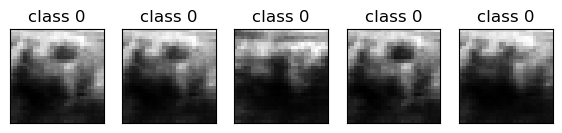

In [343]:
torch.cuda.empty_cache()
gc.collect()
generator.eval()
total_imgs_g_cls0 = torch.zeros((0, 1, 28, 28), device=device)
for i in range(20):
    torch.cuda.empty_cache()
    gc.collect()
    noise_cls0 = torch.randn((100, nz, 1, 1), device=device)
    label_cls0 = torch.tensor([[1,0]], device=device)
    input_g_cls0 = torch.cat((noise_cls0, label_cls0.repeat(100,1).unsqueeze(2).unsqueeze(3)),dim=1)
    with torch.no_grad():
        imgs_g_cls0 = generator(input_g_cls0)
    total_imgs_g_cls0 = torch.cat((total_imgs_g_cls0, imgs_g_cls0), dim=0)
fig, axs = plt.subplots(1, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(total_imgs_g_cls0):
        ax.imshow(total_imgs_g_cls0[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title('class 0')
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

In [344]:
torch.cuda.empty_cache()
gc.collect()

9957

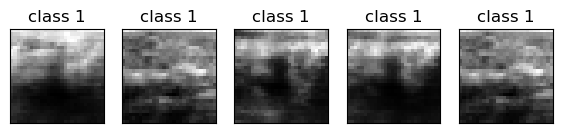

In [345]:
torch.cuda.empty_cache()
gc.collect()
generator.eval()
total_imgs_g_cls1 = torch.zeros((0, 1, 28, 28), device=device)
for i in range(20):
    torch.cuda.empty_cache()
    gc.collect()
    noise_cls1 = torch.randn((100, nz, 1, 1), device=device)
    label_cls1 = torch.tensor([[0,1]], device=device)
    input_g_cls1 = torch.cat((noise_cls1, label_cls1.repeat(100,1).unsqueeze(2).unsqueeze(3)),dim=1)
    with torch.no_grad():
        imgs_g_cls1 = generator(input_g_cls1)
    total_imgs_g_cls1 = torch.cat((total_imgs_g_cls1, imgs_g_cls1), dim=0)
fig, axs = plt.subplots(1, 5, figsize=(7, 7))
# Plot each image in a separate subplot
for i, ax in enumerate(axs.flatten()):
    if i < len(total_imgs_g_cls1):
        ax.imshow(total_imgs_g_cls1[i,0].detach().cpu().numpy(), cmap='gray')
        ax.set_title('class 1')
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

In [346]:
mix_dataset_imgs = np.concatenate((train_dataset.imgs, 
                              total_imgs_g_cls0.squeeze(1).cpu().numpy(), 
                              total_imgs_g_cls1.squeeze(1).cpu().numpy()))
mix_dataset_lbs = np.concatenate((train_dataset.labels,
                                 np.array([[0]]).repeat(2000,0),
                                 np.array([[1]]).repeat(2000,0)))

In [347]:
num_each_cls = 500
cls0_inds = np.random.randint(0, 2147, num_each_cls)
cls1_inds = np.random.randint(0, 2399, num_each_cls)
data_cls0 = mix_dataset_imgs[mix_dataset_lbs[:,0] == 0][cls0_inds]
data_cls1 = mix_dataset_imgs[mix_dataset_lbs[:,0] == 1][cls1_inds]
data_img_eq_cls = np.concatenate((data_cls0, data_cls1))
data_lbs_eq_cls = np.concatenate((np.array([[0]]).repeat(num_each_cls,0),
                                  np.array([[1]]).repeat(num_each_cls,0)))

In [350]:
# Define the transformation pipelines
torch.manual_seed(40)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=0.5, std=0.5),
])

In [351]:
# Define the custom dataset
torch.manual_seed(40)
train_dataset_forloader = MixImageDataset(data_img_eq_cls, data_lbs_eq_cls, transform=transform)
val_dataset_forloader = NumpyImageDataset(val_dataset, transform=transform)
test_dataset_forloader = NumpyImageDataset(test_dataset, transform=transform)

# Create a dataloader for the dataset
train_loader_p3_t = DataLoader(train_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
val_loader_p3_t = DataLoader(val_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)
test_loader_p3_t = DataLoader(test_dataset_forloader, batch_size=20, shuffle=True, drop_last=True)

In [352]:
gc.collect()
torch.cuda.empty_cache()

In [353]:
device = 'cuda:0'
lr = 0.001

# Initialize the model and the optimizer
torch.manual_seed(40)
model_p3_t = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model_p3_t.fc = nn.Sequential(nn.Linear(2048, 2),
                         nn.Softmax(dim=-1),)
model_p3_t = model_p3_t.to(device)
optimizer = optim.Adam(model_p3_t.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
total_epoch_counter = 0
total_epochs = 0
best_val_acc = 0

In [354]:
num_epochs = 50
total_epochs += num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    # train for one epoch
    tmp_train = train(model_p3_t, train_loader_p3_t, criterion, optimizer, device)
    train_loss[total_epoch_counter], train_acc[total_epoch_counter] = tmp_train
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_val = validate(model_p3_t, val_loader_p3_t, criterion, device)
    val_loss[total_epoch_counter], val_acc[total_epoch_counter] = tmp_val
    # print the results for this epoch
    print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.5f}, Val loss: {:.4f}, Val acc: {:.4f}'
           .format(total_epoch_counter+1, total_epochs, train_loss[total_epoch_counter], lr,
                   val_loss[total_epoch_counter], val_acc[total_epoch_counter]))
    if val_acc[total_epoch_counter] >= best_val_acc:
        best_val_acc = val_acc[total_epoch_counter]
        torch.save(model_p3_t.state_dict(), f'models/model_p3_t_{total_epoch_counter}.pth')
        print('Model saved.')
    total_epoch_counter += 1

Train. Epoch [1/50], Train loss: 0.6892, lr: 0.00100, Val loss: 0.7000, Val acc: 0.2500
Model saved.
Train. Epoch [2/50], Train loss: 0.6798, lr: 0.00100, Val loss: 0.7019, Val acc: 0.2500
Train. Epoch [3/50], Train loss: 0.6771, lr: 0.00100, Val loss: 0.7023, Val acc: 0.3000
Model saved.
Train. Epoch [4/50], Train loss: 0.6789, lr: 0.00100, Val loss: 0.7064, Val acc: 0.2500
Train. Epoch [5/50], Train loss: 0.6777, lr: 0.00100, Val loss: 0.7069, Val acc: 0.2833
Train. Epoch [6/50], Train loss: 0.6830, lr: 0.00100, Val loss: 0.7112, Val acc: 0.2333
Train. Epoch [7/50], Train loss: 0.6805, lr: 0.00100, Val loss: 0.7115, Val acc: 0.2333
Train. Epoch [8/50], Train loss: 0.6677, lr: 0.00100, Val loss: 0.7148, Val acc: 0.2333
Train. Epoch [9/50], Train loss: 0.6374, lr: 0.00100, Val loss: 0.7079, Val acc: 0.2667
Train. Epoch [10/50], Train loss: 0.5735, lr: 0.00100, Val loss: 1.0466, Val acc: 0.2667
Train. Epoch [11/50], Train loss: 0.5676, lr: 0.00100, Val loss: 0.6852, Val acc: 0.7500
Mode

In [355]:
model_p3_t.eval()
actual_labels = []
predicted_labels = []
for i, data in enumerate(test_loader_p3_t):
    inputs, labels = data[0].expand(-1,3,-1,-1).to(device), data[1].squeeze().to(device)
    with torch.no_grad():
        outputs = model_p3_t(inputs)
    loss = criterion(outputs, labels)
    torch.cuda.empty_cache()    
    predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
    predicted_labels.extend(predictions)
    actual_labels.extend(labels.cpu().numpy())

In [356]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[  0  36]
 [  0 104]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.74      1.00      0.85       104

    accuracy                           0.74       140
   macro avg       0.37      0.50      0.43       140
weighted avg       0.55      0.74      0.63       140



/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/sajad/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Axes: >

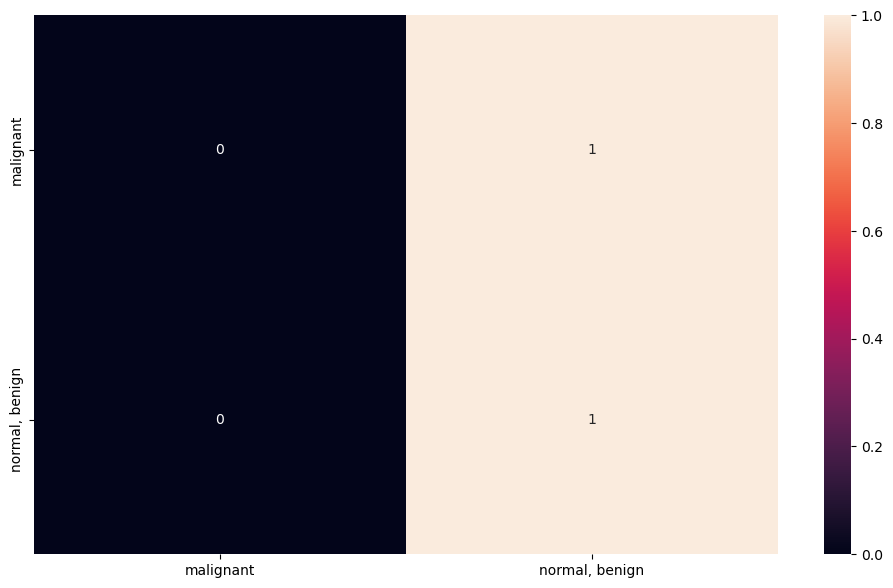

In [ ]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['malignant', 'normal, benign'], columns = ['malignant', 'normal, benign'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)